In [1]:
import sys
#%load_ext autoreload
#%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD_lab3
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

LOG.propagate = False

In [2]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-02-24 05:28:07,629 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:b4:24:2b:64
2026-02-24 05:28:07,629 | INFO     |: Scanning for device with address: c0:81:b4:24:2b:64, service UUID: 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-02-24 05:28:17,765 | INFO     |: Found 1 device(s) advertising service 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-02-24 05:28:17,776 | INFO     |: Selecting device: 38645F53-E5BF-2155-7DF0-DBDE5B0B8B54 (name: Artemis BLE)
2026-02-24 05:28:19,107 | INFO     |: Connected to c0:81:b4:24:2b:64


In [17]:
timestamps = []
tof_sensor1_data = []
def tof_sensor1_reading_notif_handler(uuid, byte_array):
    # get data from Artemis through ble
    s = ble.bytearray_to_string(byte_array)
    # split string (e.g. "Distance(mm):100,T:1234") into key-value pairs
    s_split = dict(item.split(":") for item in s.split(","))
    # append values to arrays for plotting
    tof_sensor1_data.append(int(s_split["Distance(mm)"]))
    timestamps.append(int(s_split["T"]))

In [18]:
NUM_SAMPLES = 10      # for each expected measurement
SAMPLE_DELAY = 0.15  # seconds between requests

# clear old data
timestamps.clear()
tof_sensor1_data.clear()

In [28]:
# continuously append without clearing (fill with different measured measurement)
ble.start_notify(ble.uuid['RX_STRING'], tof_sensor1_reading_notif_handler)  # FIX: added missing start_notify
for i in range(NUM_SAMPLES):
    ble.send_command(CMD_lab3.GET_SENSOR1_DATA, "")
    time.sleep(SAMPLE_DELAY)
ble.stop_notify(ble.uuid['RX_STRING'])  # FIX: was RX_STRING
print(f"Collected {len(tof_sensor1_data)} samples") # also indicate data finishes collecting!

Collected 100 samples


In [36]:
known_distances_mm = [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
d = np.array(tof_sensor1_data)
d_reshaped = d.reshape(len(known_distances_mm), NUM_SAMPLES)
means   = np.mean(d_reshaped, axis=1)
stddevs = np.std(d_reshaped,  axis=1)


<Figure size 700x500 with 0 Axes>

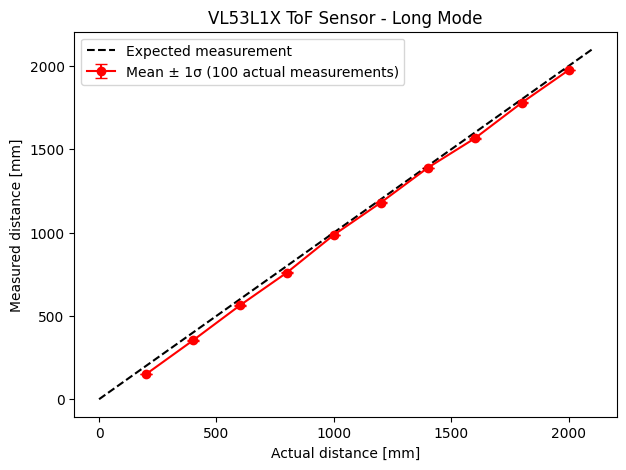

In [37]:
plt.figure(figsize=(7, 5))
plt.figure(figsize=(7, 5))
plt.errorbar(known_distances_mm, means, yerr=stddevs,
             fmt='o-', color='red', capsize=4,
             label='Mean ± 1σ (100 actual measurements)')
plt.plot([0, 2100], [0, 2100], 'k--', label='Expected measurement')
plt.xlabel("Actual distance [mm]")
plt.ylabel("Measured distance [mm]")
plt.title("VL53L1X ToF Sensor - Long Mode")
plt.legend()
plt.show()